In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1. Import Database / Data

In [3]:
conn = sqlite3.connect('my_database.db')

sql_query = """
SELECT name
FROM sqlite_master
"""

tables = pd.read_sql(sql_query, conn)

# creating dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# print table name and column names
conn = sqlite3.connect('my_database.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column info
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,CUST_1017,Gaurav Pandey,India,Madhya Pradesh,Male,1999-07-23,NaN,462001
17,CUST_1018,Ishita Agarwal,India,Haryana,Female,2000-03-14,NaN,122001
18,CUST_1019,Varun Bhatia,NaN,Chandigarh,Male,1996-09-27,NaN,160017
19,CUST_1020,Tanvi Deshmukh,India,Maharashtra,Female,1998-10-04,NaN,411001
20,CUST_1021,Harsh Vardhan,India,Bihar,Male,1995-06-18,NaN,800001


In [6]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   customerid  21 non-null     str  
 1   name        21 non-null     str  
 2   country     18 non-null     str  
 3   state       21 non-null     str  
 4   gender      21 non-null     str  
 5   dob         21 non-null     str  
 6   interests   4 non-null      str  
 7   pincode     21 non-null     str  
dtypes: str(8)
memory usage: 1.4 KB


In [7]:
# 2. Data cleaning

In [8]:
# a. rename cal - name -> customer_name
# b. drop col - interents
# c. change data type of dob - str -> date
# d. data standardization - gender
# e. fis missing values - country

In [9]:
# a.
df_db_customer.rename(columns = {'name': 'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,CUST_1001,Aarav Sharma,India,Delhi,Male,1998-05-14,"Gaming, Tech",110001
1,CUST_1002,Priya Verma,India,Maharashtra,Female,2001-08-22,"Fitness, Reading",400001
2,CUST_1003,Rohan Mehta,India,Karnataka,Male,1995-12-03,NaN,560001
3,CUST_1004,Sneha Iyer,India,Tamil Nadu,Female,1999-03-19,NaN,600001
4,CUST_1005,Kabir Gupta,India,Uttar Pradesh,Male,2002-07-11,"Coding, Music",208001
5,CUST_1006,Ananya Reddy,India,Telangana,Female,1997-11-30,NaN,500001
6,CUST_1007,Vikram Singh,India,Punjab,Male,1994-01-25,NaN,141001
7,CUST_1008,Diya Kapoor,India,Delhi,Female,2003-09-08,NaN,110016
8,CUST_1009,Arjun Nair,India,Kerala,Male,1996-04-17,NaN,682001
9,CUST_1010,Meera Joshi,India,Gujarat,Female,2000-06-05,Photography,380001


In [10]:
# b

df_db_customer.drop(columns=['interests'], inplace=True)

In [11]:
# c

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
# d

df_db_customer.replace({'gender': {'Men': 'Male', 'Women': 'Female'}}, inplace=True)

,customerid,customer_name,country,state,gender,dob,pincode
0,CUST_1001,Aarav Sharma,India,Delhi,Male,1998-05-14,110001
1,CUST_1002,Priya Verma,India,Maharashtra,Female,2001-08-22,400001
2,CUST_1003,Rohan Mehta,India,Karnataka,Male,1995-12-03,560001
3,CUST_1004,Sneha Iyer,India,Tamil Nadu,Female,1999-03-19,600001
4,CUST_1005,Kabir Gupta,India,Uttar Pradesh,Male,2002-07-11,208001
5,CUST_1006,Ananya Reddy,India,Telangana,Female,1997-11-30,500001
6,CUST_1007,Vikram Singh,India,Punjab,Male,1994-01-25,141001
7,CUST_1008,Diya Kapoor,India,Delhi,Female,2003-09-08,110016
8,CUST_1009,Arjun Nair,India,Kerala,Male,1996-04-17,682001
9,CUST_1010,Meera Joshi,India,Gujarat,Female,2000-06-05,380001


In [13]:
# e

# finding missing values if you want true/false values
# df_db_customer['country'].isna()

# if you want to see the data itself
# df_db_customer[df_db_customer['country'].isna()]

# fill the null value
# df_db_customer['country'].fillna('India')

# fill country with states as refferance
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [14]:
df_db_customer['country'] = df_db_customer['country'].fillna('India')

In [15]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,pincode
0,CUST_1001,Aarav Sharma,India,Delhi,Male,1998-05-14,110001
1,CUST_1002,Priya Verma,India,Maharashtra,Female,2001-08-22,400001
2,CUST_1003,Rohan Mehta,India,Karnataka,Male,1995-12-03,560001
3,CUST_1004,Sneha Iyer,India,Tamil Nadu,Female,1999-03-19,600001
4,CUST_1005,Kabir Gupta,India,Uttar Pradesh,Male,2002-07-11,208001
5,CUST_1006,Ananya Reddy,India,Telangana,Female,1997-11-30,500001
6,CUST_1007,Vikram Singh,India,Punjab,Male,1994-01-25,141001
7,CUST_1008,Diya Kapoor,India,Delhi,Female,2003-09-08,110016
8,CUST_1009,Arjun Nair,India,Kerala,Male,1996-04-17,682001
9,CUST_1010,Meera Joshi,India,Gujarat,Female,2000-06-05,380001


In [16]:
# Second table
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,CUST_1001,2023-01-15,Postpaid,2024-01-15,Premium,Annual,NaN,NaN,799.5,9500,12
1,CUST_1002,2022-06-10,Prepaid,2023-06-10,Basic,Monthly,2023-05-01,High Cost,299.0,3500,85
2,CUST_1003,2023-03-20,Postpaid,2024-03-20,Standard,Annual,NaN,NaN,499.0,6000,25
3,CUST_1004,2021-11-05,Prepaid,2022-11-05,Basic,Monthly,2022-10-12,Network Issue,199.0,2200,91
4,CUST_1005,2023-08-01,Postpaid,2024-08-01,Premium,Annual,NaN,NaN,999.0,12000,5
5,CUST_1006,2022-02-14,Prepaid,2023-02-14,Standard,Monthly,2023-01-10,Competitor Offer,399.5,4800,78
6,CUST_1007,2023-05-18,Postpaid,2024-05-18,Basic,Annual,NaN,NaN,249.0,3000,18
7,CUST_1008,2022-09-01,Postpaid,2023-09-01,Premium,Annual,NaN,NaN,899.0,10500,10
8,CUST_1009,2021-04-12,Prepaid,2022-04-12,Basic,Monthly,2022-03-15,Relocation,149.0,1800,88
9,CUST_1010,2023-07-22,Postpaid,2024-07-22,Standard,Annual,NaN,NaN,599.0,7200,22


In [17]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [18]:
# data cleaning
# data type change

date_col = [
    'subscription_start_date',
    'renewal_date',
    'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [19]:
# third table
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,CUST_1002,2023-04-12,2,1,None,Billing query escalated to tier 2
1,CUST_1004,2022-09-18,3,1,None,Slow speed complaint not resolved
2,CUST_1006,2023-01-05,1,2,None,Disputed extra charges on bill
3,CUST_1009,2022-03-10,2,2,None,Network downtime issue
4,CUST_1001,2023-05-10,0,5,None,NaN
5,CUST_1003,2023-03-25,0,4,None,NaN
6,CUST_1005,2023-09-02,0,5,None,NaN
7,CUST_1008,2023-01-15,0,4,None,NaN
8,CUST_1010,2023-08-01,0,5,None,NaN


In [20]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [21]:
# data cleaning
# data type and empty col delete

df_db_support.drop(columns=['col_1', 'comment'], inplace=True)
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [22]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [23]:
# 3. Feature Engineering and Data Analysis

In [24]:
# adding a col to note wheather the customer have cancelled the subscription or not donated by 1 and 0.
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [25]:
df_db_subscription.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,CUST_1001,2023-01-15,Postpaid,2024-01-15,Premium,Annual,NaT,NaN,799.5,9500,12,0
1,CUST_1002,2022-06-10,Prepaid,2023-06-10,Basic,Monthly,2023-05-01,High Cost,299.0,3500,85,1


In [26]:
# merging tables using customerid
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left') )

In [27]:
# basic hygen check that we must do every time - ['.size', '.nunique()', '.shape']

# checking wheather the merged df was correct by checking its shape (no of row X col)
df_db_subscription.shape
df.shape

# checking unique values in a table
df_db_support['customerid'].nunique()

9

In [28]:
# creating a group, then creating a new col to count the repated value, then deleting the duplicates but keeping the last/latest value.
# this will work for my db but you might need to find diff ways to delete duplicates in diff db.

# df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
# df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [29]:
# Data Analysis
# Converting the merged data frame to csv format
df.to_csv('exported_churn_data.csv', index=False)

In [30]:
# 1. Churn Rate
churnRate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churnRate, 2), "%")

# 2. Retention Rate
retentionRate = 100-churnRate
print("\nRetention Rate = ", round(retentionRate, 2), "%")

# 3. Churn by Plantype
churnByPlanType = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_per')
print("\n", churnByPlanType)

# 4. Churn by state + sum(revenue) & count of users     --- homework
churnByState = df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
stateRevenue = df.groupby('state')['cltv'].sum().reset_index(name='revenue')
countOfUsers = df.groupby('state')['customerid'].nunique().reset_index(name='customer_count')

churnByStateAndRevenue = ( churnByState
                                        .merge(stateRevenue, on='state', how='left')
                                        .merge(countOfUsers, on='state', how='left')
                         )
print("\n", churnByStateAndRevenue)

# 5. Churn by Subscription Type + sum(revenue) & count of users    --- homework
churnBySubscription = df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
subscriptionRevenue = df.groupby('subscription_type')['cltv'].sum().reset_index(name='revenue')
usersCount = df.groupby('subscription_type')['customerid'].nunique().reset_index(name='customer_count')

churnBySubscriptionAndRevenue = ( churnBySubscription
                                        .merge(subscriptionRevenue, on='subscription_type', how='left')
                                        .merge(usersCount, on='subscription_type', how='left')
                         )
print("\n", churnBySubscriptionAndRevenue)

# 6. ARPU - Avg Revenue Per User
arpu = df['monthly_charges'].mean()
print("\nARPU: ", round(arpu, 2))

# 7. Avg Customer Tenure
# count of days users has used our service: cancellation date else current date
# count of days of users age.
today = pd.Timestamp.today()
df['tenure_date'] = np.where(
    df['cancellation_date'].notna(), (df['cancellation_date'] - df['subscription_start_date']).dt.days, (today - df['subscription_start_date']).dt.days
)
df['user_age'] = np.where(
    df['cancellation_date'].notna(), (df['cancellation_date'] - df['dob']).dt.days / 365.25, (today - df['dob']).dt.days / 356.25
)

avgTenure = df['tenure_date'].mean().round()
avgUserAge = df['user_age'].mean()
print("\nAvg Tenure (days): ", avgTenure)
print("\nAvg User Age: ", avgUserAge.astype(int), " Year")

# 8. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("\nRevenue lost: ", round(revenue_at_risk))

# 9. Esclation rate
escalationRate = df['escalations'].dropna().astype(int).mean().round(2)
print("\nEscalation Rate: ", escalationRate)

# 10. Avg complaint per user
df['complaint_count'] = np.where(df['complaint_date'].notna(), 1, 0)
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("\nAvg Complaints Per User: ", round(avg_complaints, 2))

# 11. Correlation Escalation vs churn
corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("\nRelation between Escalation X Churn Rate: ", round(correlation, 2))

# 12. churn risk - create a column using escisting col
condition = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choice = ['Low', 'Med', 'High']
df['churn_risk'] = np.select(condition, choice, default='unknown')

Churn Rate =  28.57 %

Retention Rate =  71.43 %

   plan_type  churn_rate_per
0     Basic           50.00
1   Premium            0.00
2  Standard           33.33

              state  churn_rate_pct  revenue  customer_count
0            Assam             0.0     4200               1
1            Bihar             0.0    10000               1
2       Chandigarh             0.0     6000               1
3            Delhi             0.0    29600               3
4          Gujarat            50.0    12200               2
5          Haryana             0.0    11500               1
6        Karnataka             0.0     9600               2
7           Kerala           100.0     1800               1
8   Madhya Pradesh           100.0     2900               1
9      Maharashtra            50.0     7000               2
10          Punjab             0.0     3000               1
11       Rajasthan             0.0    13000               1
12      Tamil Nadu           100.0     2200            

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn_flag               21 non-null     int64         
 12  customer_name            21 non-null     str     

In [32]:
# 4. Visualization and Matplotlib

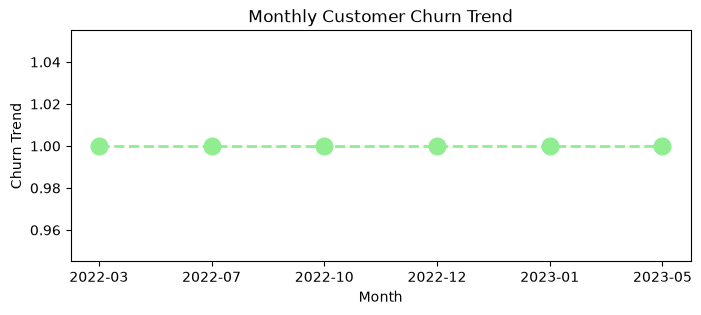

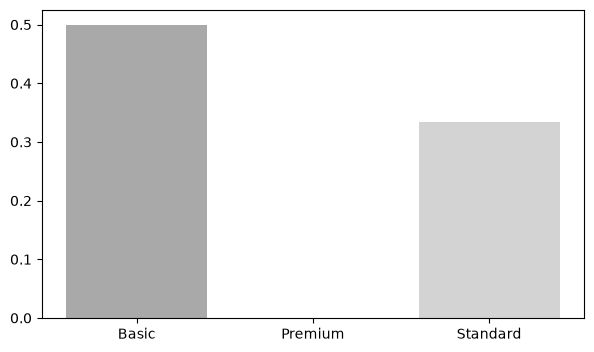

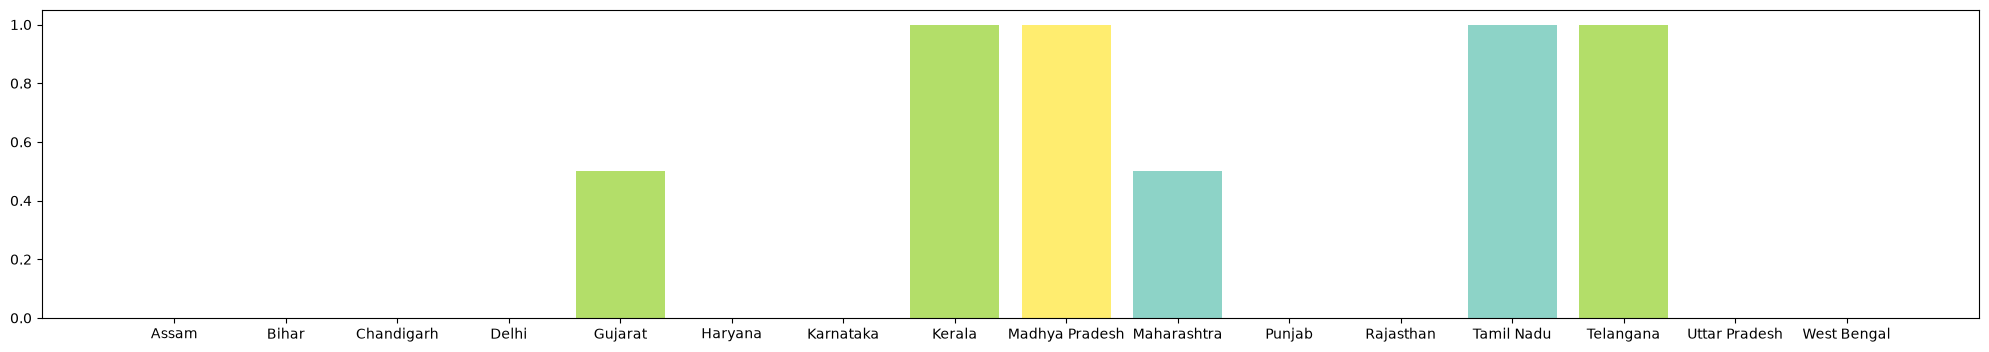

In [33]:
df_visual = df.copy()

# 1. Monthly Churn Trend (Time series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, color='lightgreen', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Customer Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churn Trend')
plt.show()

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7, 4))
colors = ['darkgray', 'cyan', 'lightgray']
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

churn_state = df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(25, 4))
colorss = plt.cm.Set3(np.linspace(0, 1, len(churn_plan)))
plt.bar(churn_state.index, churn_state.values, color = colorss)
plt.show()

<Axes: >

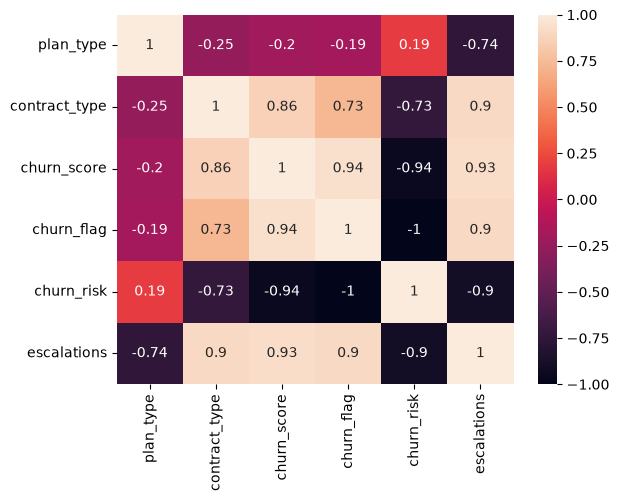

In [34]:
# Visulaization using seaborn

# -- INCORRECT Method of encoding as numbers are not based on priority --
# Encoding - convert str to num so that we can find corr between features
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]
categorial_cols = ['plan_type', 'contract_type', 'churn_risk']
for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# HeatMap (correiation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

<Axes: >

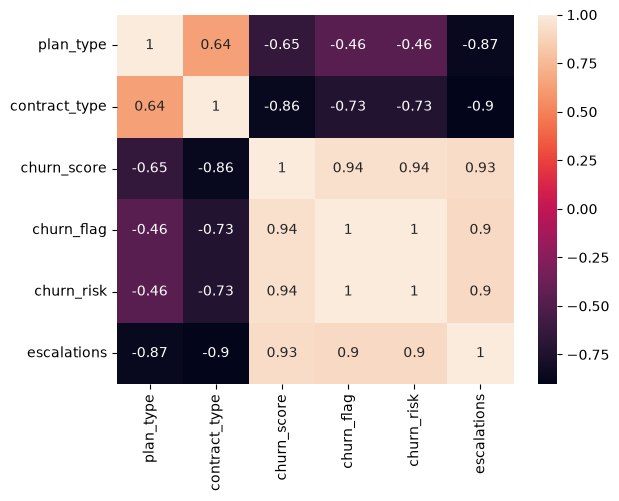

In [35]:
# -- CORRCET METHOD -- Based on Priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]
orderMapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['Low', 'Med', 'High']}
for col, order in orderMapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

sns.heatmap(df_encoded.corr(), annot=True)

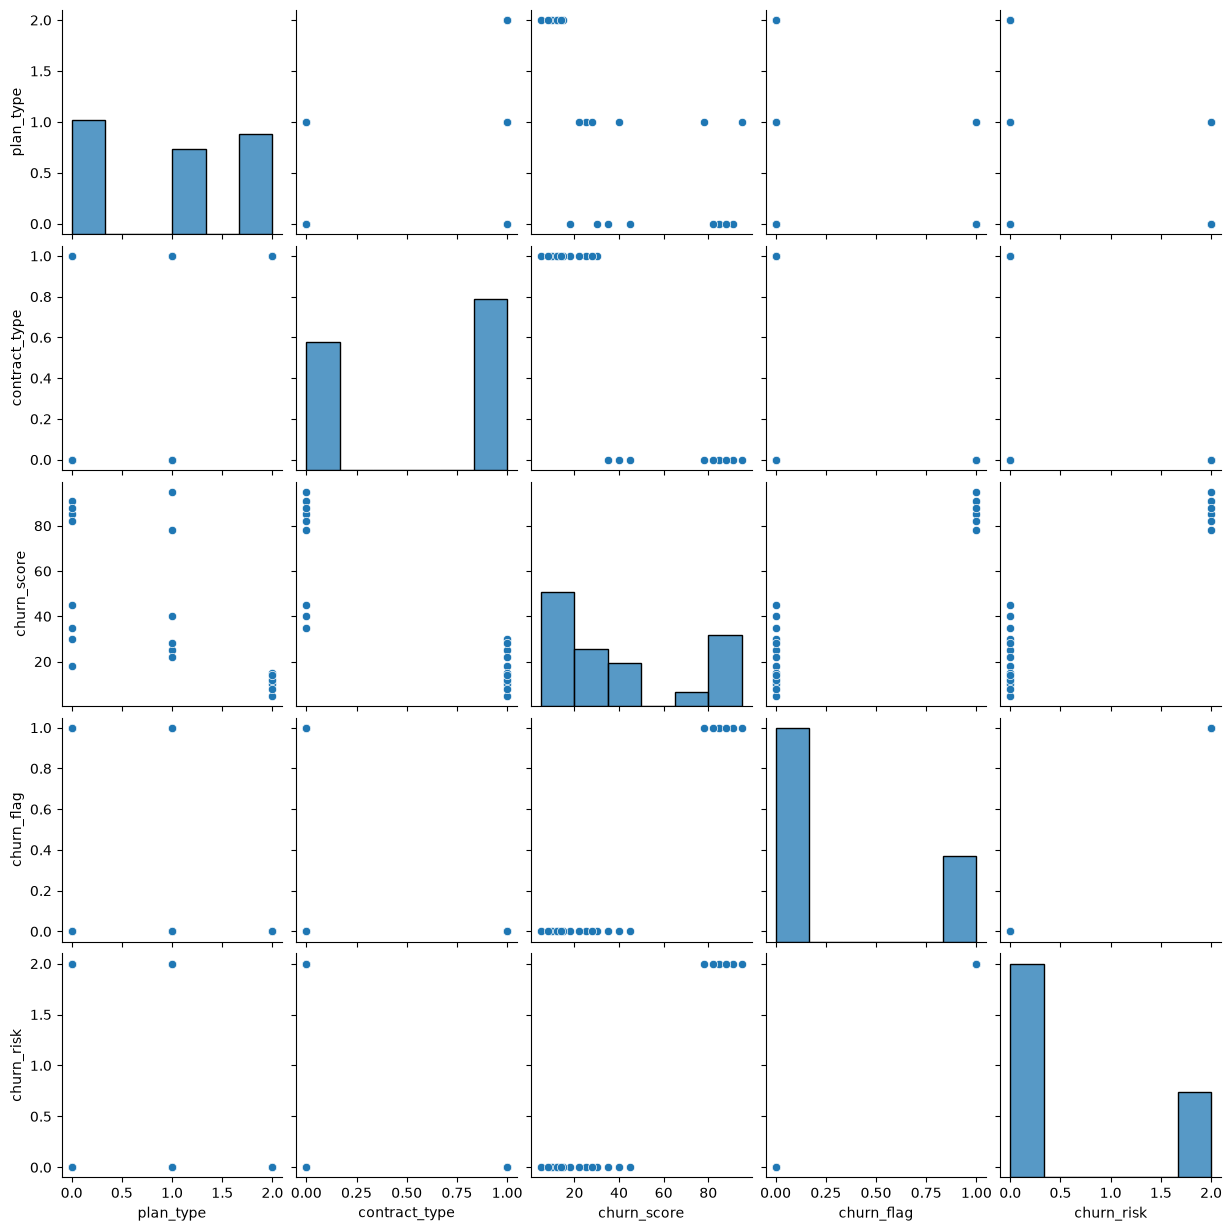

In [36]:
# PairPlot - Relationship in a dataset
sns.pairplot(df_encoded)

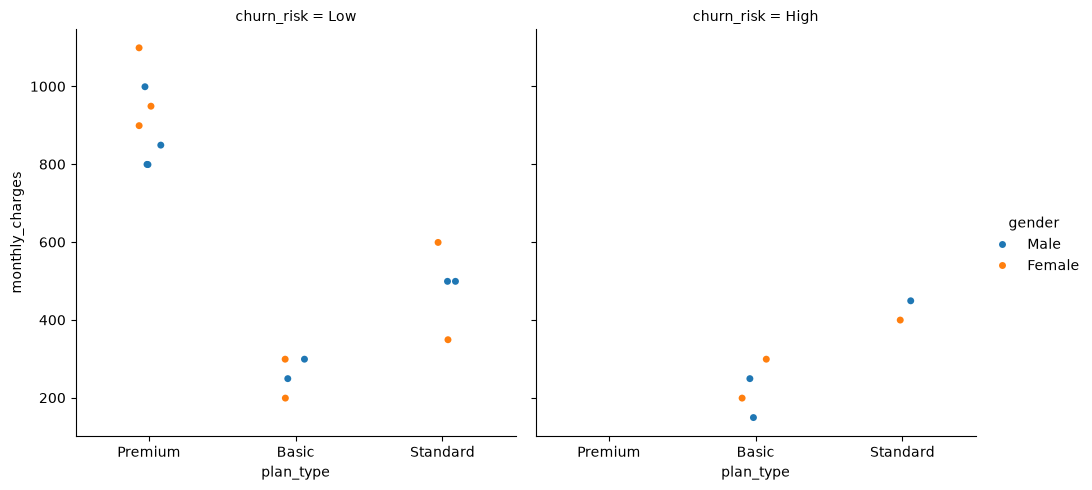

In [37]:
# Catplot/Facegrid plot - multi-dimentional comparison

sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

In [38]:
# Pivot table
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
)

pd.pivot_table(
    df_visual,
    values=['churn_flag', 'customerid', 'monthly_charges'],
    index='plan_type',
    aggfunc={'churn_flag' : 'mean',
             'customerid' : 'nunique', 
             'monthly_charges' : 'sum'}
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.500000,8,1942.0
Premium,0.000000,7,6393.5
Standard,0.333333,6,2794.5


In [39]:
# Working with SQL in Python (pandas)
# creating db in sql
conn = sqlite3.connect('test_db.sqlite')

# table details
conn.execute("CREATE TABLE IF NOT EXISTS users (first_name TEXT, country TEXT, budget INTEGER) ")

# commit and save
conn.commit()

In [40]:
# INSERT DATA
cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav', 'India', 5000),
            ('Rishabh', 'Germany', 2400),
            ('Vishakha', 'India', 3500)
    """
)

# commit and save
conn.commit()

In [41]:
# Check inserted date in table
conn = sqlite3.connect('test_db.sqlite')
query = """SELECT * FROM users"""
df_result = pd.read_sql(query, conn)
df_result

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2400
2,Vishakha,India,3400
3,Madhav,India,5000
4,Rishabh,Germany,2400
5,Vishakha,India,3500
6,Madhav,India,5000
7,Rishabh,Germany,2400
8,Vishakha,India,3500
9,Madhav,India,5000


In [42]:
# Aggregation
query = """
    SELECT country, sum(budget) as total_budget
    FROM users
    GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,12000
1,India,42400


In [43]:
conn.close()